## Channel/Noise Estimation
This notebook demonstrates an end-to-end pipeline for channel and noise estimation using the PDSCH class's ``estimateChannel`` method.

The ``estimateChannel`` function estimates the effective channel between the PDSCH layers and the receive antennas using the DMRS resource elements. It also returns ``errVar``, which is the variance of the effective residual uncertainty associated with the estimated channel. If the optional parameter ``estimateNoiseVar`` is set to ``True``, the function also returns an estimated noise variance.

This notebook compares several channel- and noise-estimation methods and evaluates their corresponding bit error rates. It also compares the estimated SNR values with the ground-truth SNR values.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

from neoradium import Carrier, PDSCH, CdlChannel, AntennaPanel, random
from neoradium.utils import toDb


Simulating end-to-end for 16QAM using perfect channel Knowledge in the frequency domain
SNR(dB)   Total Bits   Bit Errors   BER(%)   time(Sec.)
-------   ----------   ----------   ------   ----------
  -25      14976000      6125696     40.90     35.73
  -20      14976000      4988515     33.31     36.62
  -15      14976000      3416458     22.81     36.86
  -10      14976000      1790785     11.96     36.83
   -5      14976000       623667      4.16     36.63
    0      14976000       126831      0.85     36.10
    5      14976000        16749      0.11     35.75
   10      14976000          802      0.01     36.17

Simulating end-to-end for 16QAM using LS (with errVar) in the frequency domain
SNR(dB)   Total Bits   Bit Errors   BER(%)   time(Sec.)
-------   ----------   ----------   ------   ----------
  -25      14976000      6878156     45.93     37.10
  -20      14976000      5920161     39.53     37.91
  -15      14976000      4308707     28.77     38.18
  -10      14976000     

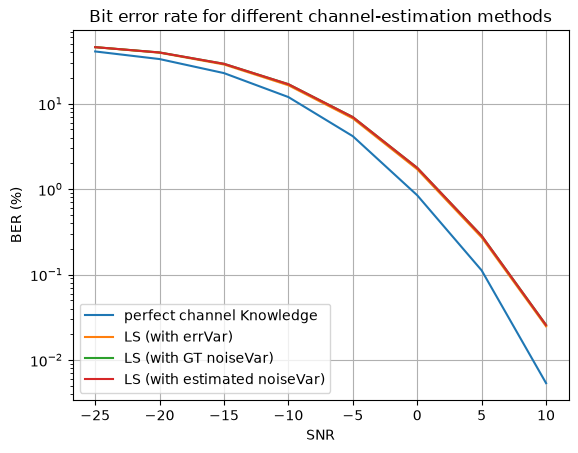

In [2]:
snrDbs = [-25, -20, -15, -10, -5, 0, 5, 10] # SNR values (in dB) for which we want to evaluate the model
freqDomain = True                           # Set to False to apply channel in the time domain

modulation = "16QAM"                        # Modulation scheme
carrier = Carrier(numRbs=24, spacing=30)    # Create a carrier with 24 RBs and 30 kHz subcarrier spacing
bwp = carrier.curBwp                        # The only bandwidth part in the carrier

# Create a PDSCH object
pdsch = PDSCH(bwp, numLayers=2, modulation=modulation)
pdsch.setDMRS(configType=1, additionalPos=1)            # DMRS configuration

numSlots = 500                                          # Total number of slots
results = {}                                            # Dictionary to save the results

noiseEstimates = {}
errVars = {}
minMse, maxMse = 100, 0
for chanEstMethod in ["perfect channel Knowledge", "LS (with errVar)", 
                      "LS (with GT noiseVar)", "LS (with estimated noiseVar)"]:
    results[chanEstMethod] = {}
    print("\nSimulating end-to-end for %s using %s in the %s domain"%
          (modulation, chanEstMethod, "frequency" if freqDomain else "time"))
    print("SNR(dB)   Total Bits   Bit Errors   BER(%)   time(Sec.)")
    print("-------   ----------   ----------   ------   ----------")
    for snrDb in snrDbs:
        if chanEstMethod=="LS (with estimated noiseVar)": 
            noiseEstimates[snrDb] = []
            errVars[snrDb] = []
        random.setSeed(123)                             # Make the results reproducible for each SNR
        t0 = time.monotonic()
        carrier.slotNo = 0

        # Create a CdlChannel object
        channel = CdlChannel(bwp, 'C', delaySpread=300, carrierFreq=4e9, dopplerShift=200,
                             txAntenna = AntennaPanel([2,4], polarization="x"),  # 16 TX antennas
                             rxAntenna = AntennaPanel([1,2], polarization="x"))  # 4 RX antennas

        bitErrors = 0
        totalBits = 0
        
        for slotNo in range(numSlots):
            pdsch.initGrid()                            # Create and initialize PDSCH's internal grid
            numBits = pdsch.getBitCapacity()            # Number of bits available in the resource grid
            txBits = random.bits(numBits[0])            # Create random binary data

            # Now populate the resource grid with coded data. This includes QAM modulation and resource mapping.
            pdsch.setPdschData(txBits)

            channelMatrix = channel.getChannelMatrix()              # Get the channel matrix
            precoder = pdsch.getPrecodingMatrix(channelMatrix)      # Get the precoder matrix

            txGrid = bwp.createGrid(len(channel.txAntenna))         # Create the transmitted resource grid
            pdsch.precodeTo(txGrid, precoder)                       # Perform the precoding
            
            if freqDomain:
                rxGrid = txGrid.applyChannel(channelMatrix)                 # Apply the channel in the frequency domain
                rxGrid = rxGrid.addNoise(snrDb=snrDb)                       # Add noise
            else:
                txWaveform = txGrid.ofdmModulate()                          # OFDM modulation
                maxDelay = channel.getMaxDelay()                            # Get the max. channel delay
                txWaveform = txWaveform.pad(maxDelay)                       # Pad with zeros
                rxWaveform = channel.applyToSignal(txWaveform)              # Apply channel in time domain
                noisyRxWaveform = rxWaveform.addNoise(snrDb=snrDb, bwp=bwp) # Add noise
                offset = channel.getTimingOffset()                          # Get timing info for synchronization
                syncedWaveform = noisyRxWaveform.sync(offset)               # Synchronization
                rxGrid = syncedWaveform.ofdmDemodulate(bwp)                 # OFDM demodulation

            if chanEstMethod == "perfect channel Knowledge":                                  
                estChannelMat = channel.getEffChannel(channelMatrix, precoder)              # Perfect channel knowledge
                eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMat)                   # Equalization
            elif chanEstMethod == "LS (with errVar)":
                estChannelMat, errVar = pdsch.estimateChannel(rxGrid)                       # LS channel estimation
                eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMat, errVar)           # Use errVar
            elif chanEstMethod == "LS (with GT noiseVar)":
                estChannelMat, errVar = pdsch.estimateChannel(rxGrid)                       # LS channel estimation
                eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMat, rxGrid.noiseVar)  # Use noiseVar
            elif chanEstMethod == "LS (with estimated noiseVar)":
                estChannelMat, errVar, estNoiseVar = pdsch.estimateChannel(rxGrid, estimateNoiseVar=True)
                eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMat, estNoiseVar)      # Use estimated noiseVar
                noiseEstimates[snrDb] += [ estNoiseVar ]
                errVars[snrDb] += [ errVar ]
            
            rxBits = pdsch.getHardBits(eqGrid)[0]                           # Demodulation
            bitErrors += np.abs(rxBits-txBits).sum()                        # Count the number of bit errors
            totalBits += numBits[0]
            print("\r  %3d      %8d     %8d    %6.2f    %6.2f"%(snrDb, totalBits, bitErrors, 
                                                                bitErrors*100/totalBits, time.monotonic()-t0), end='')

            channel.goNext()                        # Prepare the channel model for the next slot

        dt = time.monotonic()-t0                    # Total time for this SNR
        results[chanEstMethod][snrDb] = {"totalBits":totalBits, 
                                         "bitErrors":bitErrors, 
                                         "BER":      bitErrors*100/totalBits,
                                         "Time":     dt,
                                         "NoiseVar": rxGrid.noiseVar}
        print("\r  %3d      %8d     %8d    %6.2f    %6.2f"%(snrDb, totalBits, bitErrors, 
                                                            bitErrors*100/totalBits, dt))

# Compare the results
for i,chanEstMethod in enumerate(["perfect channel Knowledge", "LS (with errVar)", 
                                  "LS (with GT noiseVar)", "LS (with estimated noiseVar)"]):
    bers = [results[chanEstMethod][snrDb]["BER"] for snrDb in snrDbs]
    plt.plot(snrDbs, bers, label=chanEstMethod)
plt.legend()
plt.title("Bit error rate for different channel-estimation methods");
plt.grid()
plt.xlabel("SNR")
plt.xticks(snrDbs)
plt.ylabel("BER (%)")
plt.yscale('log')
plt.show()

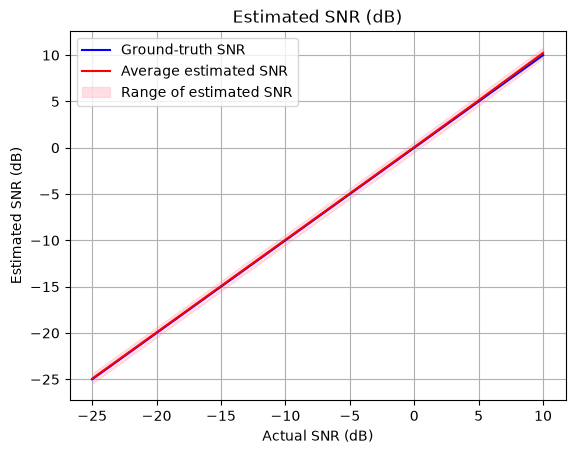

In [3]:
# Convert all estimated noise variances to SNR values and compare them with the ground-truth SNR values
nr = channel.rxAntenna.numEl
meanEstSnrDb, minEstSnrDb, maxEstSnrDb = [], [], []
for snrDb in snrDbs:
    estSnrs = toDb(1/(np.array(noiseEstimates[snrDb])*nr))      # Estimated SNR in dB
    meanEstSnrDb += [ estSnrs.mean() ]
    minEstSnrDb  += [ estSnrs.min() ]
    maxEstSnrDb  += [ estSnrs.max() ]

plt.plot(snrDbs, snrDbs, color='blue', markersize=1, label=f"Ground-truth SNR")
plt.plot(snrDbs, meanEstSnrDb, color='red', markersize=1, label=f"Average estimated SNR")
plt.fill_between(snrDbs, minEstSnrDb, maxEstSnrDb, color='pink', alpha=.5, label='Range of estimated SNR')
plt.title('Estimated SNR (dB)')
plt.xlabel('Actual SNR (dB)')
plt.ylabel('Estimated SNR (dB)')
plt.grid()
plt.legend()

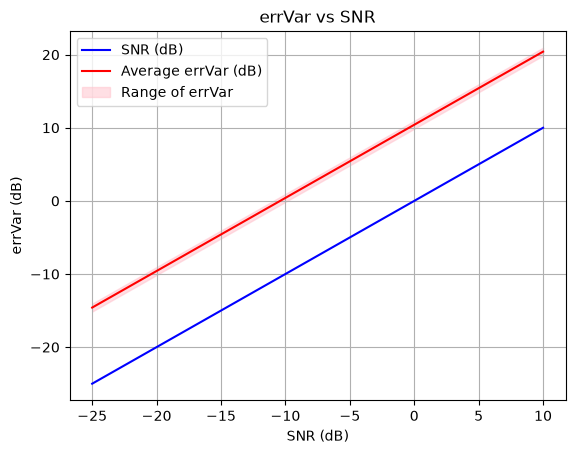

In [4]:
# Plot the residual error variance (errVar) values vs ground-truth SNR
nr = channel.rxAntenna.numEl
meanErrVarDb, minErrVarDb, maxErrVarDb = [], [], []
for snrDb in snrDbs:
    errVarDb = toDb(1/(np.array(errVars[snrDb])*nr))      # Estimated SNR in dB
    meanErrVarDb += [ errVarDb.mean() ]
    minErrVarDb  += [ errVarDb.min() ]
    maxErrVarDb  += [ errVarDb.max() ]

plt.plot(snrDbs, snrDbs, color='blue', markersize=1, label=f"SNR (dB)")
plt.plot(snrDbs, meanErrVarDb, color='red', markersize=1, label=f"Average errVar (dB)")
plt.fill_between(snrDbs, minErrVarDb, maxErrVarDb, color='pink', alpha=.5, label='Range of errVar')
plt.title('errVar vs SNR')
plt.xlabel('SNR (dB)')
plt.ylabel('errVar (dB)')
plt.grid()
plt.legend()